<a href="https://colab.research.google.com/github/khushbuchauhan820-design/Data-Science-Session/blob/main/Day5_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [6]:
np.random.seed(42)

n = 200

data = pd.DataFrame({
    "experience": np.random.randint(0, 15, n),
    "education_years": np.random.randint(10, 20, n),
    "age": np.random.randint(22, 60, n),
})

data["salary"] = (
    30000 +
    data["experience"] * 4000 +
    data["education_years"] * 2000 +
    data["age"] * 5000 +
    np.random.randn(n) * 10000
)

data.head()


,experience,education_years,age,salary
0,6,14,54,337519.156585
1,3,16,30,209925.362256
2,12,16,50,352815.557787
3,14,13,47,344865.528483
4,10,16,56,385109.075656


In [11]:
print(data.shape)
print(data.info())
print(data.describe())

(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experience       200 non-null    int64  
 1   education_years  200 non-null    int64  
 2   age              200 non-null    int64  
 3   salary           200 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 6.4 KB
None
       experience  education_years         age         salary
count  200.000000       200.000000  200.000000     200.000000
mean     7.450000        14.030000   41.480000  294590.770318
std      4.320978         2.872343   10.794545   58248.695275
min      0.000000        10.000000   22.000000  168052.436997
25%      4.000000        12.000000   33.000000  248730.107379
50%      7.500000        14.000000   43.000000  299245.520070
75%     11.000000        16.250000   51.000000  340116.418333
max     14.000000        19.000000   59.000000  395453.75949

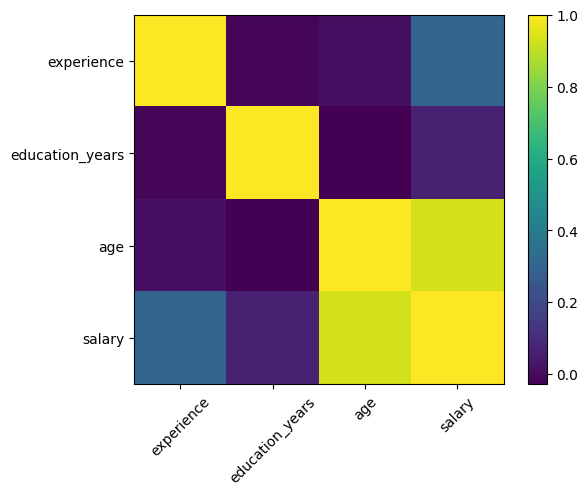

In [29]:
corr = data.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

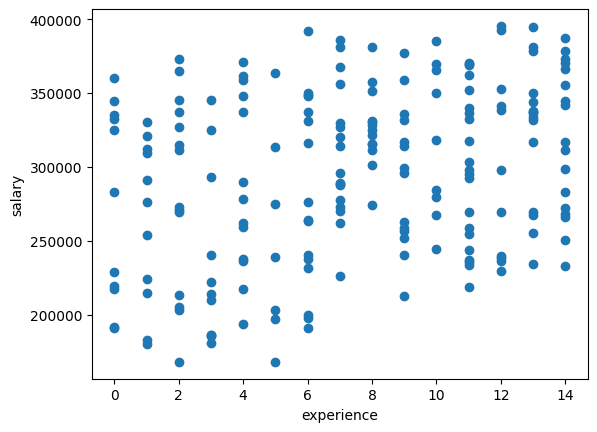

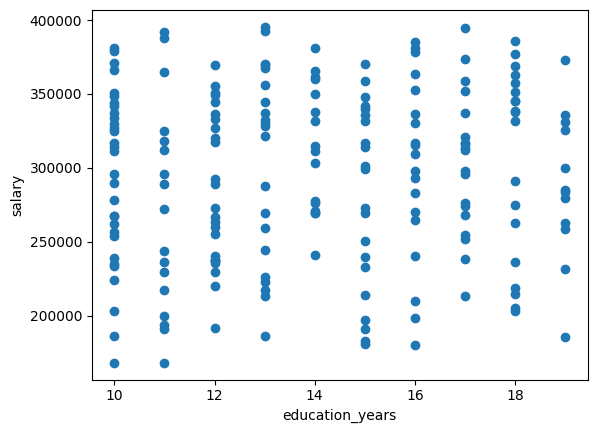

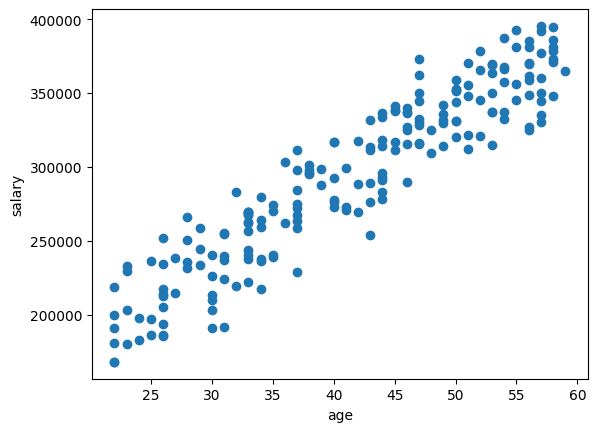

In [42]:
feature = ["experience", "education_years", "age"]

for col in feature:
    plt.figure()
    plt.scatter(data[col], data["salary"])
    plt.xlabel(col)
    plt.ylabel("salary")
    plt.show()

In [36]:
x = data[["experience", "education_years", "age"]]
y = data["salary"]


In [35]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [43]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [44]:
print(model.coef_)
print(model.intercept_)


[4010.01266984 2140.39750127 4998.99071873]
27089.505470418546


In [45]:
y_pred = model.predict(x_test)

In [50]:
27089+6*4010+14*2140+54*4998

351001

In [46]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mse, rmse, r2)


115720573.59072857 10757.349747532084 0.9687159831461813


In [47]:
new_data = pd.DataFrame({
    "experience": [5],
    "education_years": [10],
    "age": [30]
})

print(model.predict(new_data))


[218513.2653942]
